# Week 2｜PyTorch：从 Tensor 到 MNIST 训练循环

## 用卷积神经网络识别手写数字

> **本实验目标**：掌握 Tensor、自动微分、`nn.Module`、`DataLoader` 与训练/评估循环。

**最终目标**：将 `FAST_RUN` 设为 `False` 后完整训练，并尝试将测试 Accuracy 提升至 98% 以上。

---
## 0｜环境、随机种子与魔法命令

`FAST_RUN=True` 用较小数据量快速检查流程；完成代码理解后，改为 `False` 才是正式实验。

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FAST_RUN = True     # 正式提交前改为 False
print('PyTorch:', torch.__version__)
print('训练设备:', device)
print('快速模式:', FAST_RUN)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch: 2.13.0+cpu
训练设备: cpu
快速模式: True


## 1｜Tensor：深度学习中的多维数组

Tensor 与 NumPy 数组很像，但 Tensor 可以放到 GPU 并参与自动微分。

| 形状 | 含义 |
|---|---|
| `(28, 28)` | 一张 MNIST 灰度图像 |
| `(batch, 1, 28, 28)` | 一批图像；1 是灰度通道数 |
| `(batch, 10)` | 一批图像对应 10 个类别的预测分数 |

In [4]:
x = torch.arange(12).reshape(3, 4)
print('x =\n', x)
print('形状:', x.shape, '数据类型:', x.dtype)

numpy_array = np.random.randn(2, 3).astype(np.float32)
tensor_from_numpy = torch.from_numpy(numpy_array)
print('\nNumPy → Tensor：', tensor_from_numpy.shape, tensor_from_numpy.dtype)

# 标签通常使用 long；图像/模型参数通常使用 float32
label = torch.tensor(7, dtype=torch.long)
print('标签:', label, '类型:', label.dtype)

%timeit torch.randn(100, 100)
%whos

x =
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
形状: torch.Size([3, 4]) 数据类型: torch.int64

NumPy → Tensor： torch.Size([2, 3]) torch.float32
标签: tensor(7) 类型: torch.int64
46.1 μs ± 3.21 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Variable            Type       Data/Info
----------------------------------------
DataLoader          type       <class 'torch.utils.data.dataloader.DataLoader'>
FAST_RUN            bool       True
Path                type       <class 'pathlib.Path'>
SEED                int        42
Subset              type       <class 'torch.utils.data.dataset.Subset'>
datasets            module     <module 'torchvision.data<...>\\datasets\\__init__.py'>
device              device     cpu
label               Tensor     tensor(7)
nn                  module     <module 'torch.nn' from '<...>\torch\\nn\\__init__.py'>
np                  module     <module 'numpy' from 'E:\<...>ges\\numpy\\__init__.py'>
numpy_array         ndar

## 2｜自动微分：反向传播到底在做什么

`requires_grad=True` 表示需要记录该变量参与的计算。`backward()` 根据计算图自动计算导数。

对于 $z=x^2+2xy+y^3$，当 $x=2,y=3$ 时：

$$\frac{\partial z}{\partial x}=2x+2y=10, \quad \frac{\partial z}{\partial y}=2x+3y^2=31$$

In [5]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = x**2 + 2*x*y + y**3

z.backward()
print('z =', z.item())
print('dz/dx =', x.grad.item(), '（理论值：10）')
print('dz/dy =', y.grad.item(), '（理论值：31）')

# TODO：为什么训练循环的每一步都要 optimizer.zero_grad()？
# 答：_______________________________________________

z = 43.0
dz/dx = 10.0 （理论值：10）
dz/dy = 31.0 （理论值：31）


---
## 3｜加载 MNIST 与 DataLoader

`Dataset` 负责“如何取出一条样本”；`DataLoader` 负责“按 batch 取样本、打乱和迭代”。

第一次运行会把数据下载到当前目录的 `data/` 文件夹。

In [6]:
transform = transforms.ToTensor()  # 将像素从 [0, 255] 转成 float32 的 [0, 1]
data_dir = Path('data')

train_dataset_full = datasets.MNIST(data_dir, train=True, download=True, transform=transform)
test_dataset_full = datasets.MNIST(data_dir, train=False, download=True, transform=transform)

if FAST_RUN:
    train_dataset = Subset(train_dataset_full, range(8_000))
    test_dataset = Subset(test_dataset_full, range(2_000))
    epochs = 3
else:
    train_dataset = train_dataset_full
    test_dataset = test_dataset_full
    epochs = 8

batch_size = 128
pin_memory = device.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)

print('训练样本数:', len(train_dataset), '测试样本数:', len(test_dataset))
images, labels = next(iter(train_loader))
print('一个 batch 的图像形状:', images.shape)  # (batch_size, 1, 28, 28)
print('一个 batch 的标签形状:', labels.shape)  # (batch_size,)

训练样本数: 8000 测试样本数: 2000
一个 batch 的图像形状: torch.Size([128, 1, 28, 28])
一个 batch 的标签形状: torch.Size([128])


## 4｜观察一批图像

图像张量的每个样本形状是 `(1, 28, 28)`：第一个 `1` 是灰度通道。`squeeze(0)` 只是去掉这个长度为 1 的通道维度，方便 Matplotlib 显示。

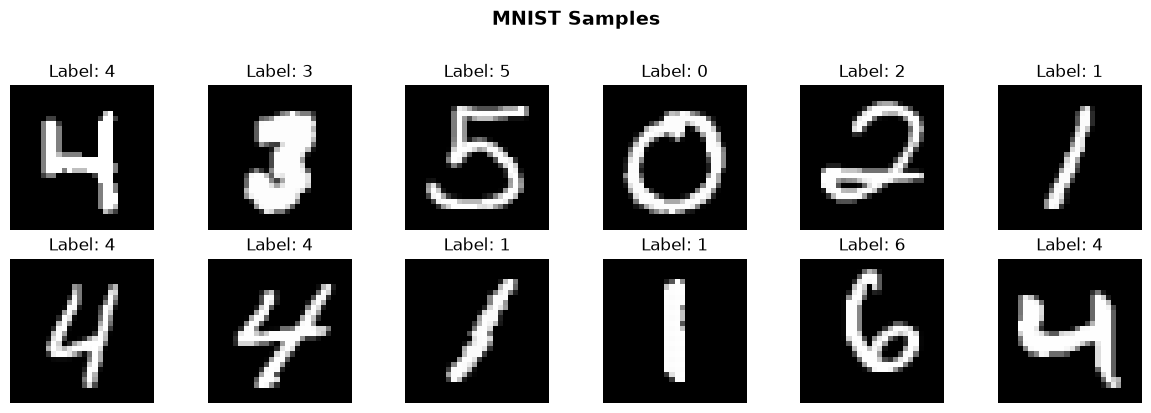

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, image, label in zip(axes.flat, images[:12], labels[:12]):
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(f'Label: {label.item()}')
    ax.axis('off')
plt.suptitle('MNIST Samples', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5｜定义 CNN 模型

网络结构：

```text
(batch, 1, 28, 28)
   → Conv + ReLU + Pool
   → Conv + ReLU + Pool
   → Flatten
   → Linear
   → (batch, 10)  # 10 个类别的原始分数 logits
```

注意：`CrossEntropyLoss` 接收 logits，因此最后一层**不需要**手动加 softmax。

In [8]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (B, 1, 28, 28) -> (B, 32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (B, 32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> (B, 64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (B, 64, 7, 7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                 # -> (B, 64 * 7 * 7)
            nn.Dropout(0.25),
            nn.Linear(64 * 7 * 7, 10),                   # -> (B, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = MNISTCNN().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'可训练参数量: {total_params:,}')

with torch.no_grad():
    demo_logits = model(images[:4].to(device))
print('模型输出形状:', demo_logits.shape)  # (4, 10)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=3136, out_features=10, bias=True)
  )
)
可训练参数量: 50,186
模型输出形状: torch.Size([4, 10])


## 6｜训练与评估函数

每个训练 batch 的固定五步：

1. `zero_grad()` 清空上一轮梯度；
2. 前向传播；
3. 计算 loss；
4. `backward()` 反向传播；
5. `step()` 根据梯度更新参数。

评估时用 `@torch.no_grad()`：不记录梯度，节省显存和时间。

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_images, batch_labels in loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = model(batch_images)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_labels.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_predictions, all_labels = [], []

    for batch_images, batch_labels in loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)
        logits = model(batch_images)
        loss = criterion(logits, batch_labels)

        total_loss += loss.item() * batch_labels.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_predictions), np.array(all_labels)

---
## 7｜开始训练

此格运行时间最长。使用 `%%time` 记录整个训练单元的耗时。每个 epoch 后记录 Loss 与 Accuracy，用于后续画训练曲线。

In [10]:
%%time
model = MNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_test_acc = 0.0

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_mnist_cnn.pth')

    print(f'Epoch {epoch:02d}/{epochs} | Train Loss {train_loss:.4f} | Train Acc {train_acc:.2%} | Test Acc {test_acc:.2%}')

print(f'\n最佳测试 Accuracy：{best_test_acc:.2%}')

Epoch 01/3 | Train Loss 0.9487 | Train Acc 73.02% | Test Acc 87.15%
Epoch 02/3 | Train Loss 0.2785 | Train Acc 91.72% | Test Acc 92.80%
Epoch 03/3 | Train Loss 0.1817 | Train Acc 94.95% | Test Acc 94.15%

最佳测试 Accuracy：94.15%
CPU times: total: 1min 24s
Wall time: 10.9 s


## 8｜训练曲线

理想情况：训练与测试 Loss 都下降，Accuracy 上升；如果训练集持续变好、测试集反而变差，可能出现过拟合。

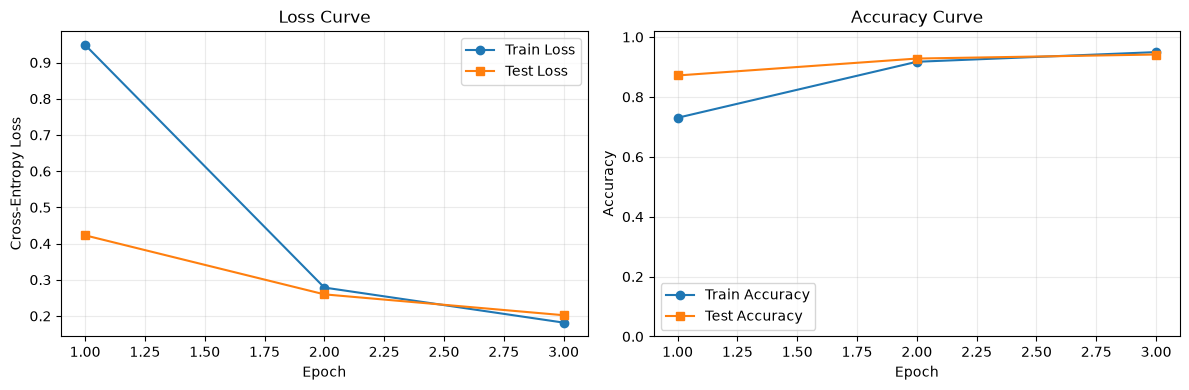

已保存图片：week2_mnist_training_curves.png


In [11]:
epochs_axis = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_axis, history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs_axis, history['test_loss'], marker='s', label='Test Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs_axis, history['train_acc'], marker='o', label='Train Accuracy')
axes[1].plot(epochs_axis, history['test_acc'], marker='s', label='Test Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('week2_mnist_training_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('已保存图片：week2_mnist_training_curves.png')

## 9｜加载最佳模型并查看预测

训练过程中保存了测试 Accuracy 最好的模型参数。这里重新加载它，再观察预测正确与错误的例子。

最终测试：Loss=0.2021，Accuracy=94.15%


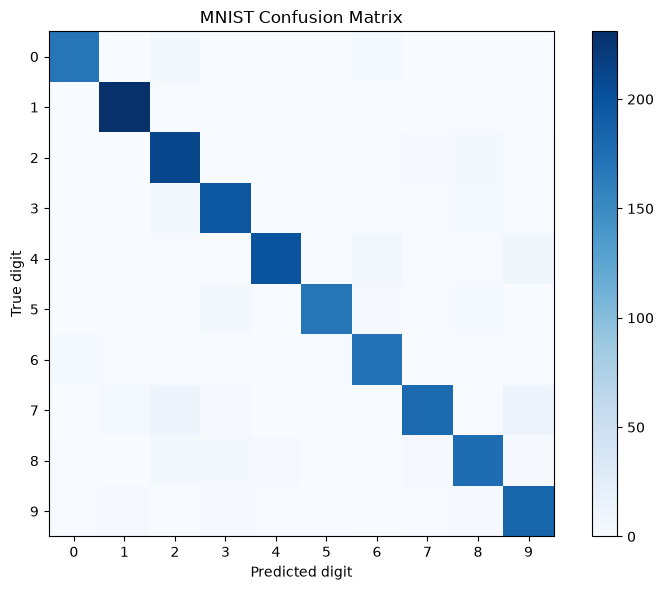

In [14]:
from sklearn.metrics import confusion_matrix

model.load_state_dict(torch.load('best_mnist_cnn.pth', map_location=device))
test_loss, test_acc, test_predictions, test_labels = evaluate(model, test_loader, criterion, device)
print(f'最终测试：Loss={test_loss:.4f}，Accuracy={test_acc:.2%}')

cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel('Predicted digit')
plt.ylabel('True digit')
plt.title('MNIST Confusion Matrix')
plt.tight_layout()
plt.show()